# Week 5 - Correlation

In [64]:
import numpy as np

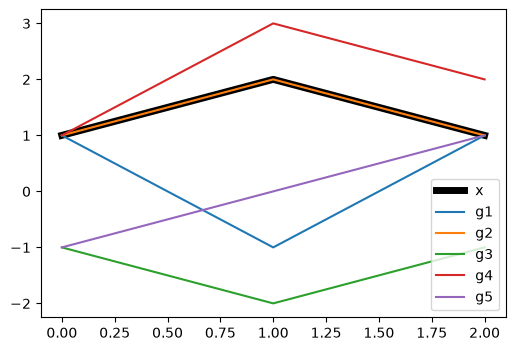

In [65]:
import matplotlib.pyplot as plt
x = [1, 2, 1]
g1 = [1, -1, 1]
g2 = [1, 2, 1]
g3 = [-1, -2, -1]
g4 = [1, 3, 2]
g5 = [-1, 0, 1]
plt.figure(figsize=(6,4))
plt.plot(x, 'k', linewidth=5)
plt.plot(g1)
plt.plot(g2)
plt.plot(g3)
plt.plot(g4)
plt.plot(g5)
plt.legend(['x', 'g1', 'g2', 'g3', 'g4', 'g5'])
plt.show()

In [66]:
# Ex1
# Correlation by hand
x_g1 = np.multiply(x, g1)
sum = np.sum(x_g1)
print(x_g1)
print(sum)

[ 1 -2  1]
0


In [67]:
x_g2 = np.multiply(x, g2)
sum = np.sum(x_g2)
print(x_g2)
print(sum)

[1 4 1]
6


In [68]:
# Correlation by own function
def correlate_sum(x, g):
    x = np.array(x)
    g = np.array(g)
    # mul = np.multiply(x, g)
    sum = np.sum(x*g)
    return sum

In [69]:
x_g2 = correlate_sum(x, g2)
print(x_g2, x_g2 == np.correlate(x, g2))

x_g3 = correlate_sum(x, g3)
print(x_g3, x_g3 == np.correlate(x, g3))

x_g4 = correlate_sum(x, g4)
print(x_g4, x_g4 == np.correlate(x, g4))

x_g5 = correlate_sum(x, g5)
print(x_g5, x_g5 == np.correlate(x, g5))

6 [ True]
-6 [ True]
9 [ True]
0 [ True]


In [70]:
# Correlation by np
print(np.correlate([1, 2, 1], [1, -1, 1]))


[0]


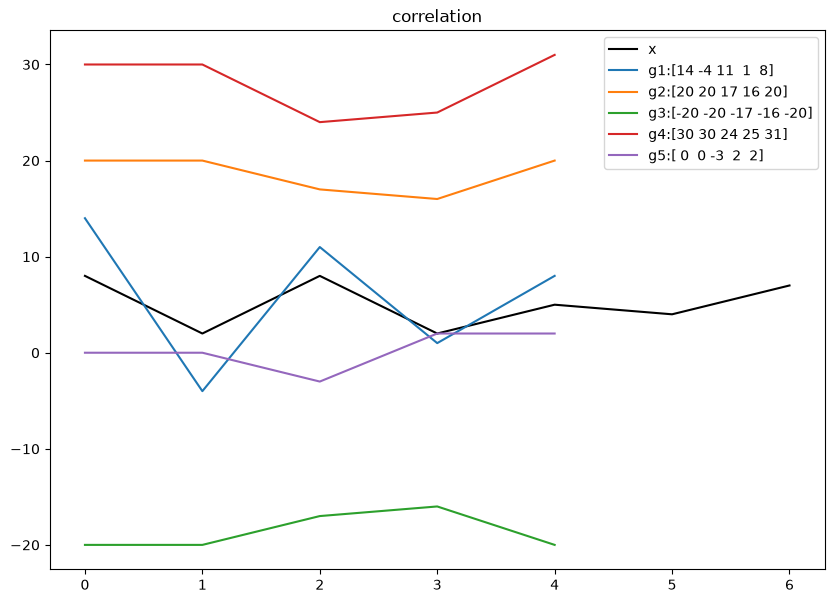

In [71]:
# Ex2 ลองกับสัญญาณที่ยาวขึ้น -> plot ค่า correlation ของ x กับ [g1, g2, g3, g4, g5]
x = [8,2,8,2,5,4,7]
x_g1 = np.correlate(x, g1)
x_g2 = np.correlate(x, g2)
x_g3 = np.correlate(x, g3)
x_g4 = np.correlate(x, g4)
x_g5 = np.correlate(x, g5)

plt.figure(figsize=(10, 7))
plt.title("correlation")
plt.plot(x, 'k')
plt.plot(x_g1)
plt.plot(x_g2)
plt.plot(x_g3)
plt.plot(x_g4)
plt.plot(x_g5)
plt.legend(['x', f"g1:{x_g1}", f"g2:{x_g2}", f"g3:{x_g3}", f"g4:{x_g4}", f"g5:{x_g5}"])
plt.savefig("image/670710258.png")
plt.show()

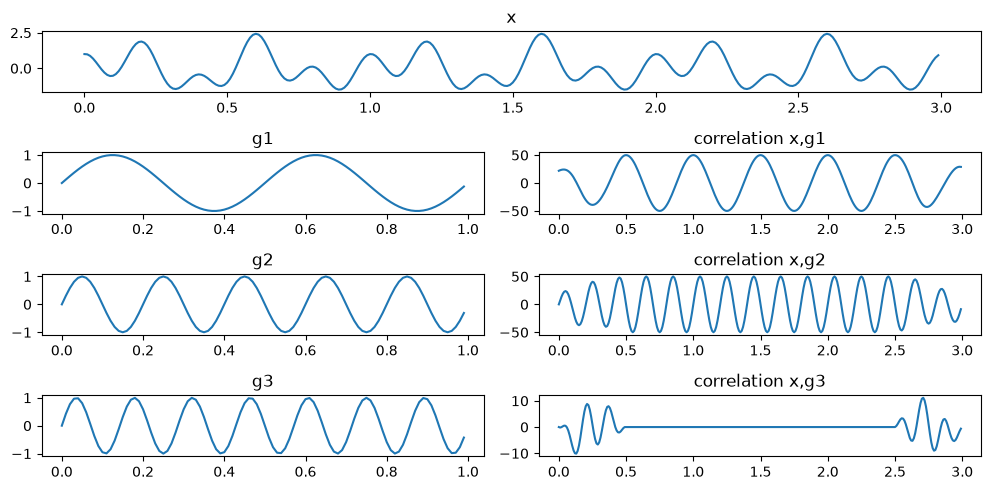

In [72]:
# Ex3 สร้างสัญญาณ sine ที่ fs=100 duration 3 ผสมจาก 3 ความถี่ 1. f=2, A=1, p=0 2. f=3, A=0.5, p=pi 3. f=5, A=1, p=pi/2
# สร้างสัญญาณ template ที่ fs=100 duration 1 เพื่อใช้ทำ correlation
# 1. f=2, 2. f=5, 3. f=7
def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

fs = 100
duration = 3

t = time_axis( fs, duration )
x1 = generate_sine(2, t, 1, 0)
x2 = generate_sine(3, t, 0.5, np.pi)
x3 = generate_sine(5, t, 1, np.pi/2)

x = x1 + x2 + x3

#create template with less time
t_template = time_axis(fs, 1)
g1 = generate_sine(2, t_template)
g2 = generate_sine(5, t_template)
g3 = generate_sine(7, t_template)

plt.figure(figsize = (10, 5))
plt.subplot(4, 1, 1)
plt.title("x")
plt.plot(t, x)

plt.subplot(4, 2, 3)
plt.title("g1")
plt.plot(t_template, g1)

plt.subplot(4, 2, 4)
plt.title("correlation x,g1")
plt.plot(t, np.correlate(x, g1, mode = "same"))

plt.subplot(4, 2, 5)
plt.title("g2")
plt.plot(t_template, g2)

plt.subplot(4, 2, 6)
plt.title("correlation x,g2")
plt.plot(t, np.correlate(x, g2, mode = "same"))

plt.subplot(4, 2, 7)
plt.title("g3")
plt.plot(t_template,g3)

plt.subplot(4, 2, 8)
plt.title("correlation x,g3")
plt.plot(t, np.correlate(x, g3, mode = "same"))

plt.tight_layout()
plt.savefig("image/670710258.png")
plt.show()

In [80]:
# print(np.correlate(x, g1, mode = "same"))
# print(np.correlate(x, g2, mode = "same"))
print(np.correlate(x, g3, mode = "same"))

[-2.80710788e-15 -1.85582065e-01 -2.41550128e-02  3.02075620e-01
  5.50262399e-01  4.74428297e-01 -1.14209413e-01 -1.29677516e+00
 -3.01704178e+00 -5.07945646e+00 -7.17642519e+00 -8.94058040e+00
 -1.00126672e+01 -1.01123200e+01 -9.09804101e+00 -7.00435828e+00
 -4.04815138e+00 -6.01761228e-01  2.86330860e+00  5.85269700e+00
  7.93216673e+00  8.80242699e+00  8.35219071e+00  6.67962075e+00
  4.07793198e+00  9.87353119e-01 -2.07827471e+00 -4.61740143e+00
 -6.22406475e+00 -6.65397708e+00 -5.86196175e+00 -4.00452518e+00
 -1.40767386e+00  1.49367180e+00  4.23330118e+00  6.39414049e+00
  7.67703506e+00  7.94588775e+00  7.24177826e+00  5.76459352e+00
  3.82676318e+00  1.78877355e+00 -1.07159318e-02 -1.31667521e+00
 -1.99987672e+00 -2.07199920e+00 -1.67168969e+00 -1.02536620e+00
 -3.91467416e-01  1.45261178e-14  1.81682297e-14  1.99202631e-14
  2.18115549e-14  2.08980050e-14  1.98100062e-14  1.87777476e-14
  1.65142697e-14  1.62962222e-14  1.71278809e-14  1.82342809e-14
  1.67083344e-14  1.30635

+ meaning: when we use the frequency : 2, 5, 7 to check the frequency what will be the result
+ correlation is searching for pattern, if that signal has the freq. we want and where is that frequency

# Week 5 - Complex numbers as magnitude and angle

In [61]:
vec = [3, 4] # 3+4j
magnitude = np.sqrt(np.sum(np.pow(vec, 2))) # หรือ np.linalg.norm(vec) หรือ np.abs( 3+4j )
angle = np.rad2deg(np.arctan2(4, 3))
# angle = np.rad2deg(np.arctan(4/3))
print(magnitude, angle)

5.0 53.13010235415598


In [77]:
# Ex4
# 5+12j
vec = [5, 12]
magnitude = np.sqrt(np.sum(np.pow(vec, 2)))
angle = np.rad2deg(np.arctan(12/5))
print(magnitude, angle)
# 6+8j
vec = [6, 8]
magnitude = np.sqrt(np.sum(np.pow(vec, 2)))
angle = np.rad2deg(np.arctan(8/6))
print(magnitude, angle)
# 7+24j
vec = [7, 24]
magnitude = np.sqrt(np.sum(np.pow(vec, 2)))
angle = np.rad2deg(np.arctan(24/7))
print(magnitude, angle)

13.0 67.38013505195958
10.0 53.13010235415598
25.0 73.73979529168804


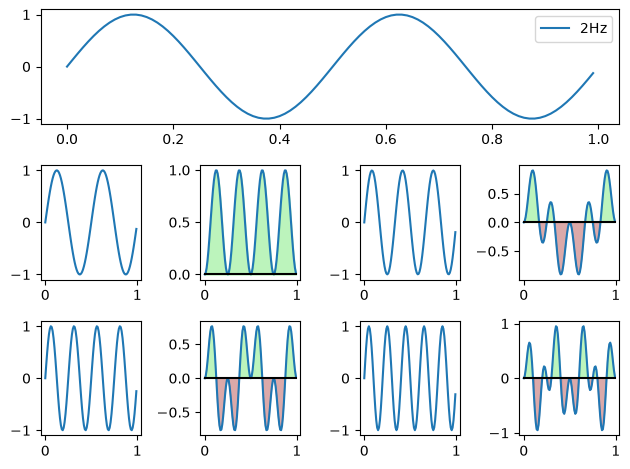

In [92]:
fs = 100
duration = 1
t = time_axis(fs, duration)
x = generate_sine(2, t) 
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.legend( ['2Hz'] )

#create template
index = 5
for f in [2, 3, 4, 5]:
    g = generate_sine(f, t)
    plt.subplot(3, 4, index)
    index = index + 1
    plt.plot(t, g)
    y = x*g
    plt.subplot(3, 4, index)
    index += 1
    plt.plot(t, y)
    plt.plot(t, np.zeros(len(t)), 'k')
    plt.fill_between(t, y, where = (y>=0), color = "lightgreen", alpha = 0.6)
    plt.fill_between(t, y, where = (y<0), color = "brown", alpha = 0.4)
plt.tight_layout()

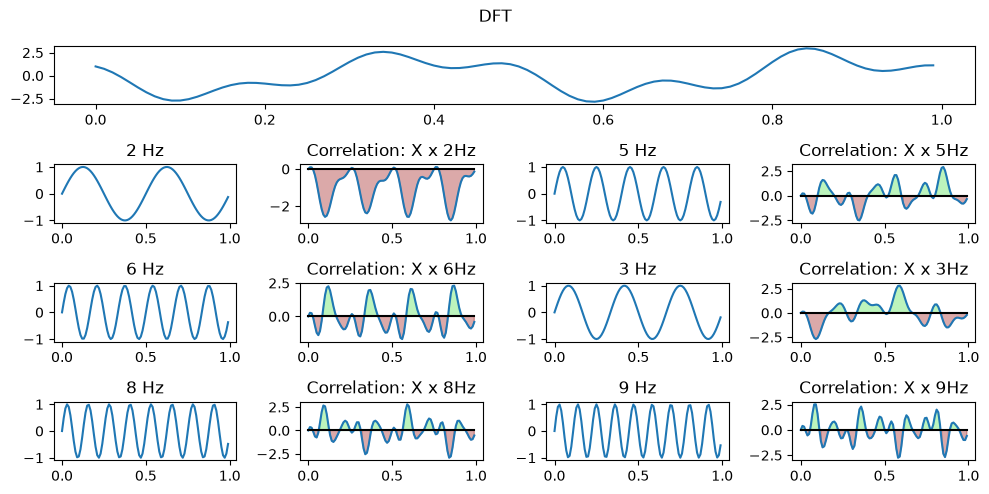

In [116]:
# Ex 5 สร้างสัญญาณผสมอย่างน้อย 3 ความถี่ จากนั้นสร้างสัญญาณ sine ความถี่เดี่ยว 6 ความถี่ และแสดงผลการทำ correlation
fs = 100
# if duration = 10 , can't identify the signals, cause it makes too many sample
duration = 1

t = time_axis(fs, duration)
x1 = generate_sine(5, t, 0.2, 0)
x2 = generate_sine(2, t, 2, np.pi)
x3 = generate_sine(6, t, 1, np.pi/2)
x = x1 + x2 + x3

plt.figure(figsize=(10, 5))
plt.subplot(4, 1, 1)
plt.plot(t, x)


index = 5

for f in [ 2, 5, 6, 3, 8, 9 ]:
    g = generate_sine(f, t)
    plt.subplot(4, 4, index)
    index = index + 1
    plt.plot(t, g)
    plt.title(f'{f} Hz')
    y = x*g
    plt.subplot(4, 4, index)
    index += 1
    plt.plot(t, y)
    plt.plot(t, np.zeros(len(t)), 'k')
    plt.title(f'Correlation: X x {f}Hz')
    plt.fill_between(t, y, where = (y>=0), color = "lightgreen", alpha = 0.6)
    plt.fill_between(t, y, where = (y<0), color = "brown", alpha = 0.4)
plt.suptitle("DFT")
plt.tight_layout()
plt.savefig("image/670710258.png")

# Week 5 - The Discrete Fourier Transform

In [95]:
# Ex 6
x = np.array([1.0, 0.0, -1.0, 0.0])
k=0
n=0
np.exp(-1j*2*np.pi*k*n/4)

np.complex128(1+0j)

In [104]:
def dft_matrix(N):
    n = np.arange(N)
    k = np.arange(N)[:, None]
    return np.exp(-2j*np.pi*k*n/N)
F = dft_matrix(4)
print(np.round(F))

[[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
 [ 1.+0.j -1.-0.j  1.+0.j -1.-0.j]
 [ 1.+0.j -0.+1.j -1.-0.j  0.-1.j]]


In [107]:
def dft_direct(x):
    x = np.asarray(x, dtype=complex)
    return dft_matrix(len(x)) @ x

x = np.array([1.0, 0.0, -1.0, 0.0])
X = dft_direct(x)

print('X =', np.round(X4))

X = [0.+0.j 2.+0.j 0.-0.j 2.+0.j]


In [ ]:
# Ex6 จากสัญญาณข้อ 5 เพิ่มสัญญาณรบกวนเข้าไป 1. sine ที่ความถี่ 0.5, A=2 2. สัญญาณสุ่ม np.random.normal(min, max, n)
